# 第086课：真实PyTorch迁移与训练循环
从Python对象和迭代桥梁开始，再做三层数值对齐。缺少PyTorch必须报错，不跳过或模拟。

In [1]:
import json, platform
from pathlib import Path
import numpy as np
import torch
from experiment import *
print({'python':platform.python_version(),'numpy':np.__version__,'torch':torch.__version__,'device':str(DEVICE),'dtype':str(DTYPE)})

{'python': '3.12.14', 'numpy': '2.3.5', 'torch': '2.14.1+cpu', 'device': 'cpu', 'dtype': 'torch.float64'}


## 1 类、继承、实例与方法
两个实例拥有各自状态，super完成基类初始化。

In [2]:
class Counter:
    def __init__(self,start=0): self.value=start
    def add(self,amount): self.value+=amount; return self.value
class NamedCounter(Counter):
    def __init__(self,name,start=0):
        super().__init__(start); self.name=name
a=NamedCounter('train'); b=NamedCounter('validation'); a.add(3)
print(a.name,a.value,b.name,b.value)

train 3 validation 0


## 2 迭代器与生成器
观察耗尽；新epoch应建立新遍历。

In [3]:
def mini_batches(values,size):
    for start in range(0,len(values),size):
        yield values[start:start+size]
it=mini_batches(list(range(5)),3)
print(next(it)); print(next(it))
try:
    next(it)
except StopIteration:
    print('iterator exhausted')
print('new traversal:',list(mini_batches(list(range(5)),3)))

[0, 1, 2]
[3, 4]
iterator exhausted
new traversal: [[0, 1, 2], [3, 4]]


## 3 Dataset/DataLoader与参数形状
标签为long，特征为float64；尾批只有3条。

In [4]:
data=load_data(); loaders=make_loaders(data)
print([(tuple(X.shape),tuple(y.shape),str(X.dtype),str(y.dtype)) for X,y in loaders['train']])
model=TwoLayer(3)
print([(name,tuple(p.shape),p.numel()) for name,p in model.named_parameters()])

[((32, 2), (32,), 'torch.float64', 'torch.int64'), ((32, 2), (32,), 'torch.float64', 'torch.int64'), ((32, 2), (32,), 'torch.float64', 'torch.int64'), ((32, 2), (32,), 'torch.float64', 'torch.int64'), ((32, 2), (32,), 'torch.float64', 'torch.int64'), ((32, 2), (32,), 'torch.float64', 'torch.int64'), ((32, 2), (32,), 'torch.float64', 'torch.int64'), ((32, 2), (32,), 'torch.float64', 'torch.int64'), ((32, 2), (32,), 'torch.float64', 'torch.int64'), ((32, 2), (32,), 'torch.float64', 'torch.int64'), ((3, 2), (3,), 'torch.float64', 'torch.int64')]
[('first.weight', (3, 2), 6), ('first.bias', (3,), 3), ('second.weight', (2, 3), 6), ('second.bias', (2,), 2)]


## 4 三层对齐
同参数、同输入、同平均损失、同SGD更新。

In [5]:
print(json.dumps(parity_audit(),indent=2))

{
  "dtype": "torch.float64",
  "device": "cpu",
  "torch_version": "2.14.1+cpu",
  "loss_numpy": 0.6888129044681032,
  "loss_torch": 0.6888129044681032,
  "loss_abs_error": 0.0,
  "logits_max_abs": 1.1102230246251565e-16,
  "gradient_max_abs": {
    "W1": 1.734723475976807e-17,
    "b1": 3.469446951953614e-17,
    "W2": 2.7755575615628914e-17,
    "b2": 5.551115123125783e-17
  },
  "step_max_abs": {
    "W1": 0.0,
    "b1": 2.6020852139652106e-18,
    "W2": 0.0,
    "b2": 3.469446951953614e-18
  },
  "checked_scalar_parameters": 17
}


## 5 累积、清空和detach断链
重新前向不等于清空旧梯度。

In [6]:
print(accumulation_audit())
x=torch.tensor(2.,requires_grad=True); z=(x*x).detach()
print('detached requires_grad:',z.requires_grad)
try:
    z.backward()
except RuntimeError as exc:
    print('Expected detach error:',str(exc).splitlines()[0])

{'first': 30.0, 'second_without_zero': 60.0, 'after_reset': 30.0, 'interpretation': '30 + 30 = 60 at unchanged w; intentional accumulation requires correct loss scaling'}
detached requires_grad: False
Expected detach error: element 0 of tensors does not require grad and does not have a grad_fn


## 6 状态与梯度记录分别控制
主迁移模型没有Dropout，状态差异单独演示。

In [7]:
print(state_audit())

{'dropout_train_zero_fraction': 0.506, 'dropout_eval_all_ones': True, 'eval_alone_requires_grad': True, 'eval_with_no_grad_requires_grad': False}


## 7 完整训练、验证选型与一次测试
固定训练指标使用单独的不打乱加载器，不影响训练随机顺序。

In [8]:
result=run()
Path('outputs').mkdir(exist_ok=True)
Path('outputs/notebook-result.json').write_text(json.dumps(result,indent=2))
print({k:v for k,v in result['training'].items() if k!='history'})

{'seed': 8601, 'shuffle_seed': 8602, 'epochs': 180, 'batch_size': 32, 'learning_rate': 0.15, 'last_train_batch_size': 3, 'last_validation_batch_size': 29, 'initial_train': {'loss': 0.9381430627079685, 'accuracy': 0.48297213622291024, 'examples': 323}, 'best_epoch': 180, 'final': {'train': {'loss': 0.005283997061723629, 'accuracy': 1.0, 'examples': 323}, 'validation': {'loss': 0.01367580591389577, 'accuracy': 0.9936305732484076, 'examples': 157}, 'test': {'loss': 0.009206824812022892, 'accuracy': 1.0, 'examples': 160}}, 'weighted_validation_vs_full_numpy_abs': 3.469446951953614e-18}


## 8 真正的unittest验收

In [9]:
import unittest
from test_experiment import FrameworkTests
tests=unittest.TextTestRunner(verbosity=1).run(unittest.defaultTestLoader.loadTestsFromTestCase(FrameworkTests))
if not tests.wasSuccessful():
    raise RuntimeError('Framework tests failed')

...........
----------------------------------------------------------------------
Ran 11 tests in 0.988s

OK


## 9 重建并显示四图

01_layout_bridge.png
02_gradient_accumulation.png
03_training_validation.png
04_parity_errors.png


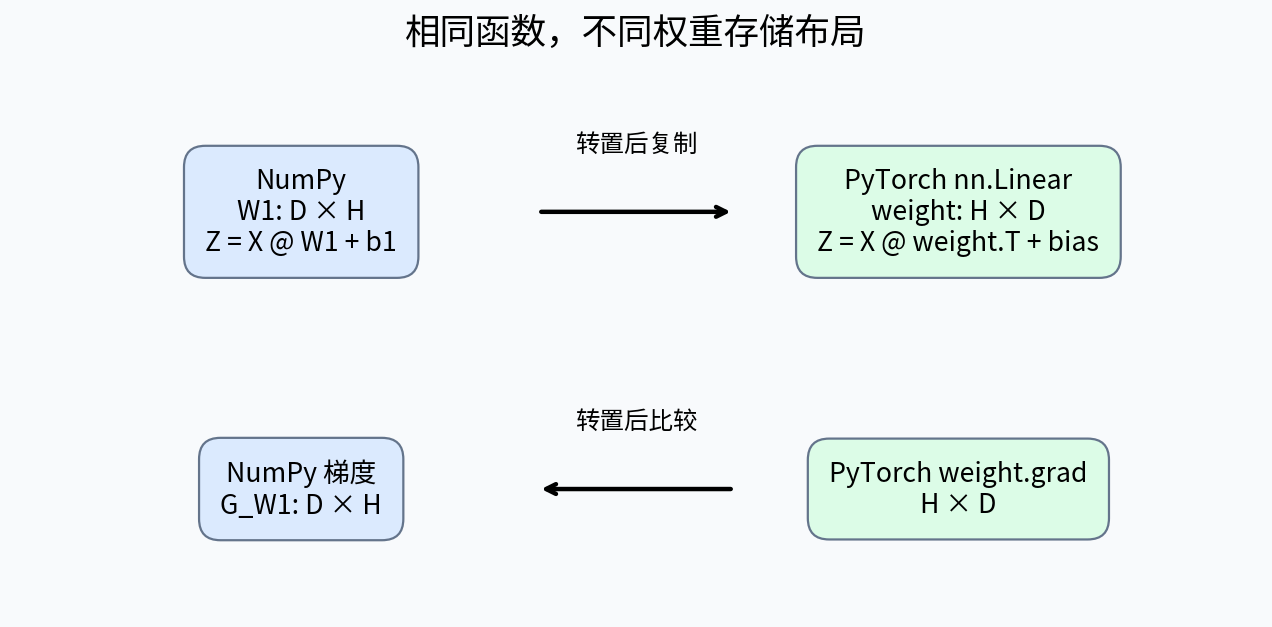

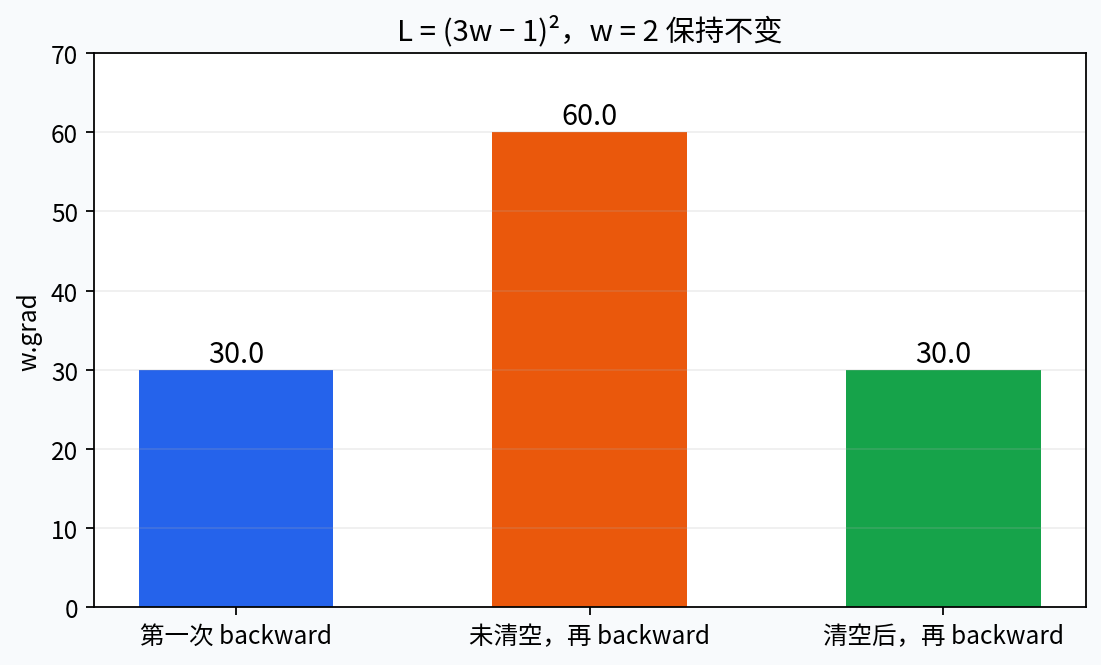

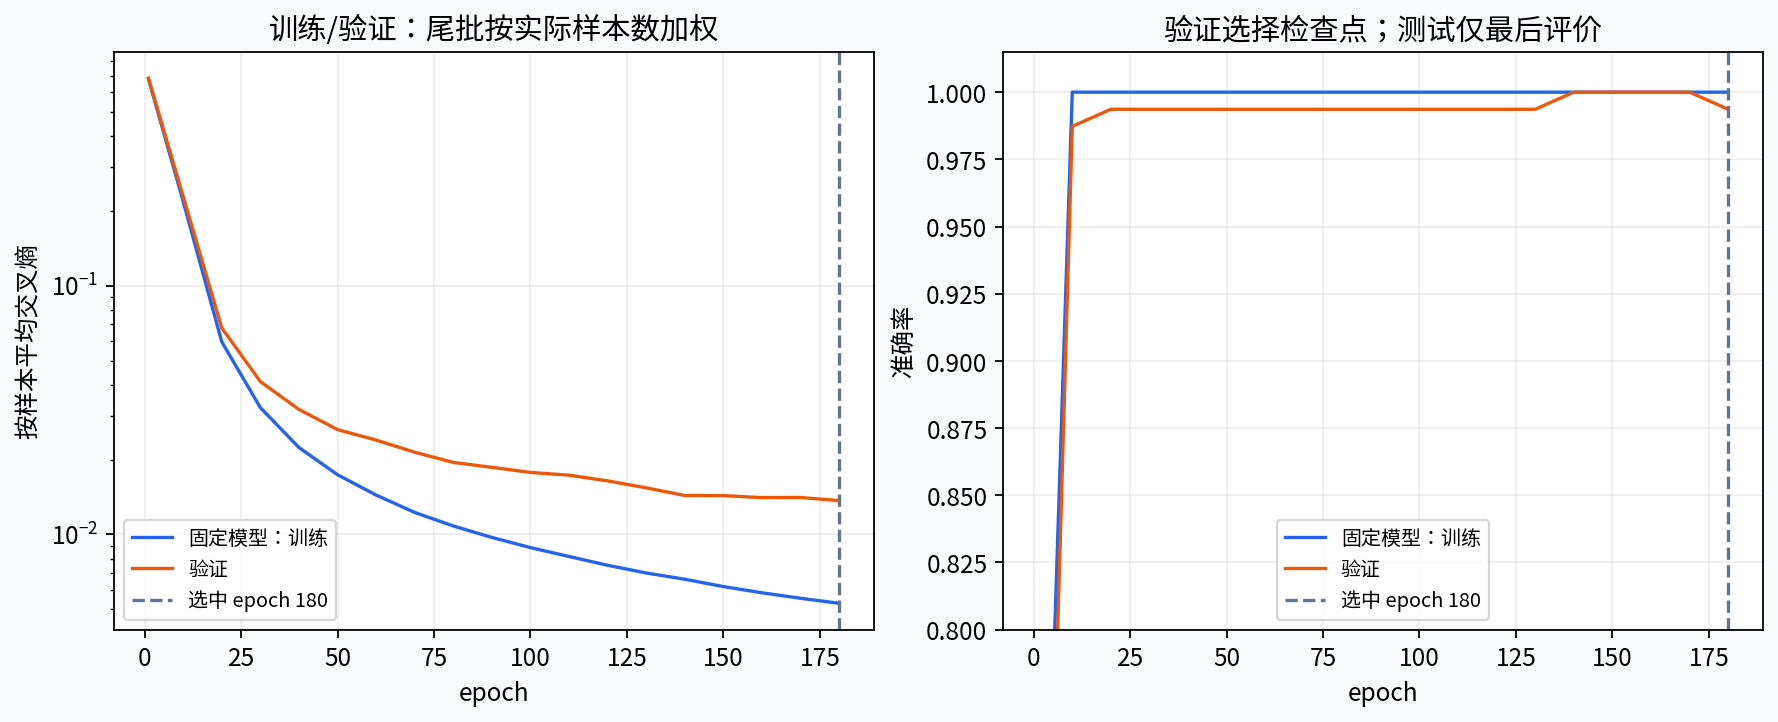

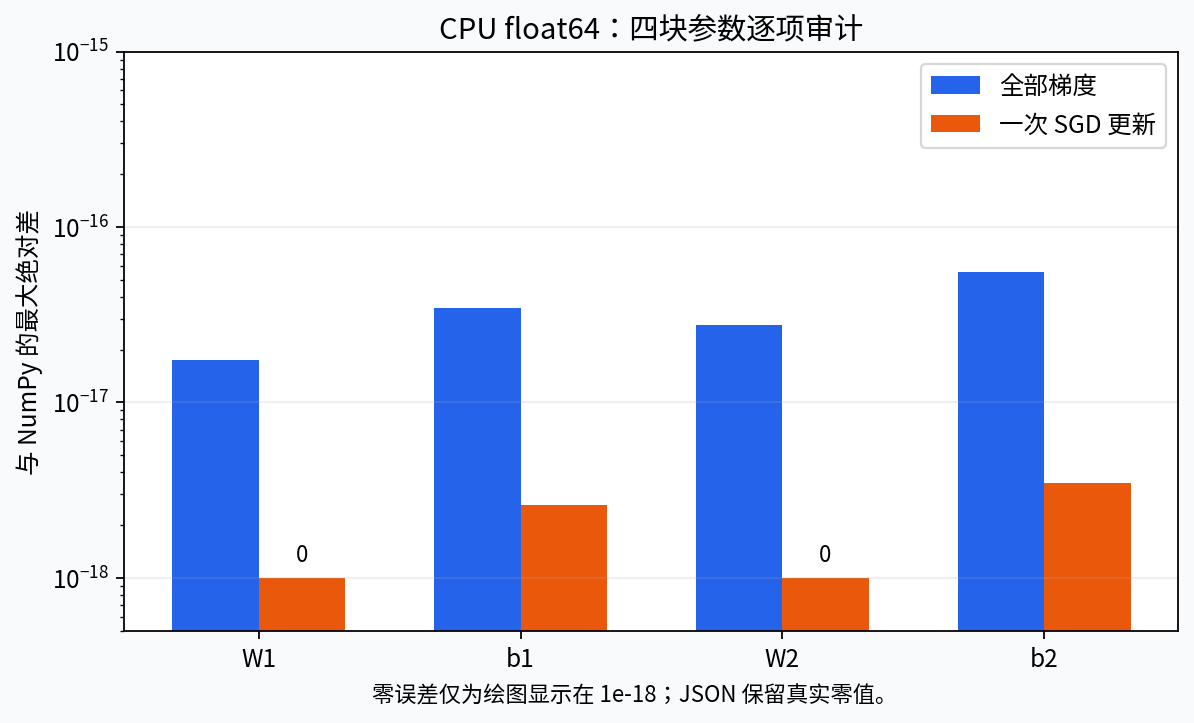

In [10]:
from plots import main as plot_all
from IPython.display import Image, display
for path in plot_all('outputs/notebook-figures','outputs/notebook-result.json'):
    print(Path(path).name)
    display(Image(filename=path))

## 结论边界
CPU迁移验收不代表GPU已测试；两讲训练预算不同，不能根据最终损失宣布框架优劣。继续完成lab.md的9题。